# 01 — Data exploration

First look at the raw fab data: which tables we have, what columns they contain,
and what each row represents.

> `lot_process_table.csv` is too large for GitHub and is stored as `data/lot_process_table.zip`. Unzip it into `data/` before running this notebook.

In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

data_dir = Path("../data")

In [18]:
# just 5 rows per file to see what's inside
for f in sorted(data_dir.glob("*.csv")):
    df = pd.read_csv(f, nrows=5, sep=None, engine="python")
    print("=" * 60)
    print(f.name)
    print("columns:", list(df.columns))
    print(df.head())

interopt_table.csv
columns: ['WORKSHOP', 'MACHINE', 'RECIPE']
      WORKSHOP       MACHINE       RECIPE
0  LITHOGRAPHY  MACHINE_0007  RECIPE_0001
1  LITHOGRAPHY  MACHINE_0001  RECIPE_0001
2  LITHOGRAPHY  MACHINE_0014  RECIPE_0001
3  LITHOGRAPHY  MACHINE_0027  RECIPE_0001
4  LITHOGRAPHY  MACHINE_0030  RECIPE_0001
lot_arrival_table.csv
columns: ['LOT', 'PRODUCT', 'ARRIVAL_DATE', 'DUE_DATE']
            LOT       PRODUCT   ARRIVAL_DATE       DUE_DATE
0  LOT_00000001  PRODUCT_0003  1672527600000  1677625200000
1  LOT_00000002  PRODUCT_0001  1672530480000  1677628080000
2  LOT_00000003  PRODUCT_0003  1672533360000  1677630960000
3  LOT_00000004  PRODUCT_0002  1672536240000  1677633840000
4  LOT_00000005  PRODUCT_0001  1672539120000  1677636720000
lot_process_table.csv
columns: ['LOT', 'PRODUCT', 'OPERATION', 'MACHINE', 'PROCESS_BEGIN_DATE', 'PROCESS_END_DATE']
            LOT       PRODUCT       OPERATION       MACHINE  \
0  LOT_00000002  PRODUCT_0001  OPERATION_0001  MACHINE_0073   
1  LOT

## Load the full tables

Dates are Unix timestamps in milliseconds, converted to datetimes below.
`lot_process_table` has no workshop or recipe, so we join it with `product_route_table2`
on (PRODUCT, OPERATION).

In [19]:
# load all
def read_table(path):
    # files don't all use the same separator, we check the header line
    with open(path) as fh:
        header = fh.readline()
    sep = ";" if header.count(";") > header.count(",") else ","
    df = pd.read_csv(path, sep=sep)
    df.columns = df.columns.str.strip()  # just in case of stray spaces
    return df

tables = {}
for f in sorted(data_dir.glob("*.csv")):
    tables[f.stem] = read_table(f)

for name, df in tables.items():
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} cols")

interopt_table: 2,658 rows x 3 cols
lot_arrival_table: 21,931 rows x 4 cols
lot_process_table: 1,755,296 rows x 6 cols
machine_breakdown_table: 277,107 rows x 3 cols
machine_table: 130 rows x 4 cols
product_route_table2: 361 rows x 4 cols


In [20]:
# Convert dates
date_cols = {
    "lot_arrival_table": ["ARRIVAL_DATE", "DUE_DATE"],
    "lot_process_table": ["PROCESS_BEGIN_DATE", "PROCESS_END_DATE"],
    "machine_breakdown_table": ["BREAKDOWN_BEGIN_DATE", "BREAKDOWN_END_DATE"],
}

# timestamps are in ms
for name, cols in date_cols.items():
    for c in cols:
        tables[name][c] = pd.to_datetime(tables[name][c], unit="ms")

tables["lot_arrival_table"].head()

,LOT,PRODUCT,ARRIVAL_DATE,DUE_DATE
0,LOT_00000001,PRODUCT_0003,2022-12-31 23:00:00,2023-02-28 23:00:00
1,LOT_00000002,PRODUCT_0001,2022-12-31 23:48:00,2023-02-28 23:48:00
2,LOT_00000003,PRODUCT_0003,2023-01-01 00:36:00,2023-03-01 00:36:00
3,LOT_00000004,PRODUCT_0002,2023-01-01 01:24:00,2023-03-01 01:24:00
4,LOT_00000005,PRODUCT_0001,2023-01-01 02:12:00,2023-03-01 02:12:00


In [23]:
# add workshop and recipe
process = tables["lot_process_table"].merge(
    tables["product_route_table2"],
    on=["PRODUCT", "OPERATION"],
    how="left",
)

process["PROCESS_TIME_MIN"] = (
    process["PROCESS_END_DATE"] - process["PROCESS_BEGIN_DATE"]
).dt.total_seconds() / 60

# should be 0 if every operation matched a route step
print("missing workshop:", process["WORKSHOP"].isna().sum())
process.head()

missing workshop: 0


,LOT,PRODUCT,OPERATION,MACHINE,PROCESS_BEGIN_DATE,PROCESS_END_DATE,WORKSHOP,RECIPE,PROCESS_TIME_MIN
0,LOT_00000002,PRODUCT_0001,OPERATION_0001,MACHINE_0073,2022-12-31 23:48:00.000,2023-01-01 00:27:08.620,ETCHING,RECIPE_0061,39.143667
1,LOT_00000002,PRODUCT_0001,OPERATION_0002,MACHINE_0004,2023-01-01 00:27:08.620,2023-01-01 01:12:47.903,LITHOGRAPHY,RECIPE_0010,45.654717
2,LOT_00000001,PRODUCT_0003,OPERATION_0001,MACHINE_0077,2022-12-31 23:00:00.000,2023-01-01 01:38:39.181,ETCHING,RECIPE_0099,158.653017
3,LOT_00000004,PRODUCT_0002,OPERATION_0001,MACHINE_0102,2023-01-01 01:24:00.000,2023-01-01 02:10:17.189,IMPLEMENTATION,RECIPE_0301,46.286483
4,LOT_00000003,PRODUCT_0003,OPERATION_0001,MACHINE_0100,2023-01-01 00:36:00.000,2023-01-01 02:44:46.914,ETCHING,RECIPE_0099,128.781900


In [24]:
# first numbers
print("from", process["PROCESS_BEGIN_DATE"].min(), "to", process["PROCESS_END_DATE"].max())
print()
print(process["WORKSHOP"].value_counts())
print()
process.groupby("WORKSHOP")["PROCESS_TIME_MIN"].describe()

from 2022-12-31 23:00:00 to 2024-12-31 22:58:09.301000

WORKSHOP
LITHOGRAPHY       614186
ETCHING           604442
IMPLEMENTATION    536668
Name: count, dtype: int64



,count,mean,std,min,25%,50%,75%,max
WORKSHOP,,,,,,,,
ETCHING,604442.0,99.935839,74.903048,0.000033,47.663925,79.874717,132.386442,1227.443100
IMPLEMENTATION,536668.0,54.585825,30.385119,0.000200,33.336221,48.666775,69.280613,703.911833
LITHOGRAPHY,614186.0,67.982590,47.559600,0.001667,39.409479,58.702425,82.977075,1101.492800


## Waiting times

The data has no queue-entry timestamp, so we rebuild it:
a lot joins the next queue as soon as its previous operation ends,
and joins the first queue when it arrives in the fab.

*Waiting time = process begin − queue entry*

In [26]:
# calculate the waiting time for each operation
arrivals = tables["lot_arrival_table"][["LOT", "ARRIVAL_DATE"]]

process = process.sort_values(["LOT", "OPERATION"]).reset_index(drop=True)

# end of the previous op of the same lot
process["QUEUE_ENTRY"] = process.groupby("LOT")["PROCESS_END_DATE"].shift(1)

# first op -> lot enters the queue when it arrives
process = process.merge(arrivals, on="LOT", how="left")
process["QUEUE_ENTRY"] = process["QUEUE_ENTRY"].fillna(process["ARRIVAL_DATE"])

process["WAIT_MIN"] = (
    process["PROCESS_BEGIN_DATE"] - process["QUEUE_ENTRY"]
).dt.total_seconds() / 60

print("negative waits:", (process["WAIT_MIN"] < 0).sum())
process["WAIT_MIN"].describe()

negative waits: 0


count    1.755296e+06
mean     8.351676e+01
std      1.733764e+02
min      0.000000e+00
25%      3.512967e+00
50%      2.573440e+01
75%      8.850712e+01
max      7.959635e+03
Name: WAIT_MIN, dtype: float64

In [27]:
# waiting by workshop
wait_by_ws = process.groupby("WORKSHOP")["WAIT_MIN"].agg(["mean", "median", "sum"])
wait_by_ws["share_of_total_wait"] = wait_by_ws["sum"] / wait_by_ws["sum"].sum()
wait_by_ws.round(2)

,mean,median,sum,share_of_total_wait
WORKSHOP,,,,
ETCHING,71.08,33.69,42966237.94,0.29
IMPLEMENTATION,14.89,3.68,7991828.63,0.05
LITHOGRAPHY,155.72,71.83,95638564.16,0.65


In [28]:
lots_per_product = process.groupby("PRODUCT")["LOT"].nunique()

# hours of waiting per lot, split by workshop
wait_per_lot = (
    process.groupby(["PRODUCT", "WORKSHOP"])["WAIT_MIN"].sum()
    .unstack()
    .div(lots_per_product, axis=0)
    / 60
)
wait_per_lot.round(1)

WORKSHOP,ETCHING,IMPLEMENTATION,LITHOGRAPHY
PRODUCT,,,
PRODUCT_0001,21.3,3.9,41.9
PRODUCT_0002,58.7,16.8,215.7
PRODUCT_0003,30.0,3.5,61.4
PRODUCT_0004,46.7,9.7,79.5


## Machine utilization

Share of the 2-year period each machine spends processing, averaged per workshop.

In [29]:
# usage rate
horizon_min = (
    process["PROCESS_END_DATE"].max() - process["PROCESS_BEGIN_DATE"].min()
).total_seconds() / 60

busy_min = process.groupby(["WORKSHOP", "MACHINE"])["PROCESS_TIME_MIN"].sum()
utilization = (busy_min / horizon_min).groupby("WORKSHOP").mean()
utilization.round(3)

WORKSHOP
ETCHING           0.956
IMPLEMENTATION    0.928
LITHOGRAPHY       0.992
Name: PROCESS_TIME_MIN, dtype: float64

### Takeaways

- No negative waiting time, so the queue-entry rule holds
- LITHOGRAPHY accounts for 65% of all waiting in the fab (mean 156 min per operation)
- It is the main source of waiting for every product; PRODUCT_0002 is hit hardest (~216 h per lot)
- Utilization: LITHOGRAPHY 99.2%, ETCHING 95.6%, IMPLEMENTATION 92.8%
- LITHOGRAPHY is the bottleneck: highest utilization and by far the most waiting

## Workshop occupation over time

- `L_machine`: lots being processed (= busy machines)
- `L_workshop`: lots in the workshop, queued or processed
- queue size = L_workshop − L_machine

Built by adding +1 when a lot enters and −1 when it leaves, then taking a running sum.

In [30]:
# Nbr of machines per workshop
tables["machine_table"]["WORKSHOP"].value_counts()

WORKSHOP
ETCHING           60
LITHOGRAPHY       40
IMPLEMENTATION    30
Name: count, dtype: int64

In [31]:
# Occupancy 
def occupancy(start, end):
    # +1 when a lot comes in, -1 when it leaves, running sum = lots inside
    events = pd.concat([
        pd.Series(1, index=start.values),
        pd.Series(-1, index=end.values),
    ])
    level = events.groupby(level=0).sum().sort_index().cumsum()

    # read the level at every hour
    grid = pd.date_range(level.index.min().floor("h"), level.index.max().ceil("h"), freq="h")
    return level.reindex(level.index.union(grid)).ffill().reindex(grid).fillna(0)


wip = {}
for ws, g in process.groupby("WORKSHOP"):
    wip[ws] = pd.DataFrame({
        "L_workshop": occupancy(g["QUEUE_ENTRY"], g["PROCESS_END_DATE"]),
        "L_machine": occupancy(g["PROCESS_BEGIN_DATE"], g["PROCESS_END_DATE"]),
    })

wip["LITHOGRAPHY"].describe()

,L_workshop,L_machine
count,17544.000000,17544.000000
mean,130.569368,39.665698
std,27.028335,1.800079
min,0.000000,0.000000
25%,116.000000,40.000000
50%,132.000000,40.000000
75%,148.000000,40.000000
max,212.000000,40.000000


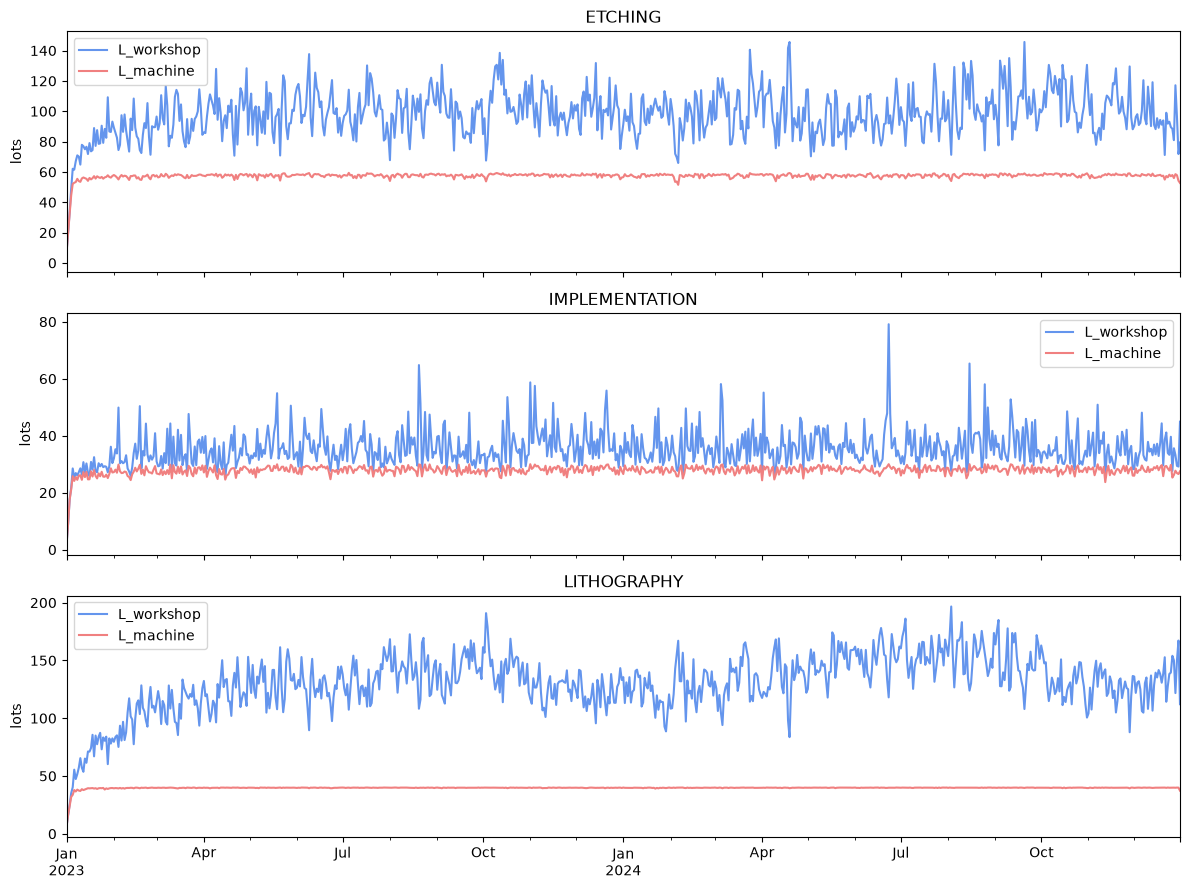

In [39]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ax, (ws, df) in zip(axes, wip.items()):
    df.resample("D").mean().plot(ax=ax, color=[ "#6495ED", "#F08080" ])  # daily mean, hourly is too noisy
    ax.set_title(ws)
    ax.set_ylabel("lots")

plt.tight_layout()
plt.show()

### Takeaways

- Data covers **2 years** (Jan 2023 – Dec 2024)
- LITHOGRAPHY: all 40 machines busy almost all the time, ~90 lots queued on average,
  and the queue absorbs all the variability
- ETCHING: ~57–58 of 60 machines busy, ~40 lots queued
- IMPLEMENTATION: ~28 of 30 machines busy, small queue (~8 lots)
- The fab starts empty: LITHOGRAPHY takes ~2–3 months to reach steady state
  (warm-up period to handle when validating the twin)